<a href="https://colab.research.google.com/github/Saloni-Shaw/Data-Analytics-Projects/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Analysis

This project analyzes telecom customer data to identify factors that contribute to customer churn and to provide actionable business insights for improving customer retention.

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Customer Churn Prediction.csv to Customer Churn Prediction.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Problem Statement

Customer churn is a major challenge for telecom companies. Losing customers reduces revenue and increases customer acquisition costs.

The goal of this analysis is to identify patterns and factors that contribute to customer churn so that the company can take proactive measures to improve customer retention.

In [ ]:
df=pd.read_csv("Customer Churn Prediction.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

## Dataset Overview

The dataset contains telecom customer information including demographics, services used, billing information, and churn status.

Number of records: 7043 customers  
Number of features: 21 columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


This step helps understand the dataset structure, column types, and overall data distribution.

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
df["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


Approximately 27% of customers have churned while 73% remain active.
This indicates that a considerable number of customers leave the service, highlighting the importance of analyzing factors that contribute to churn

In [ ]:
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


In [ ]:
pd.crosstab(df["gender"],df["Churn"], normalize="index")*100

Churn,No,Yes
gender,,
Female,254900,93900
Male,262500,93000


Churn rate is almost identical between male and female customers.
This suggests that gender does not significantly influence customer churn

In [ ]:
pd.crosstab(df["SeniorCitizen"],df["Churn"], normalize="index")*100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


Senior Citizens churn more frequently

In [ ]:
pd.crosstab(df["Partner"], df["Churn"], normalize="index")*100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


Customers without Partners show higher churn rates

In [ ]:
pd.crosstab(df["Dependents"], df["Churn"], normalize="index")*100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


Customers with dependents tend to saty longer

In [ ]:
pd.crosstab(["tenure"],df["Churn"],normalize="index")*100

Churn,No,Yes
row_0,,
tenure,73.463013,26.536987


In [ ]:
df["Contract"].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


In [ ]:
pd.crosstab(df["Contract"],df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [ ]:
pd.crosstab(df["Contract"],df["Churn"], normalize="index")*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


###Contract Type vs Churn
Customers with month-to-month contracts show the highest churn rate.
Customers with one-year and two-year contracts have significantly lower churn rates.
This suggests that long term contracts increase customer retention

###Business Statergy
The company should encourage customers to switch from month-to-month contracts by offering discounts or loyalty benefits.

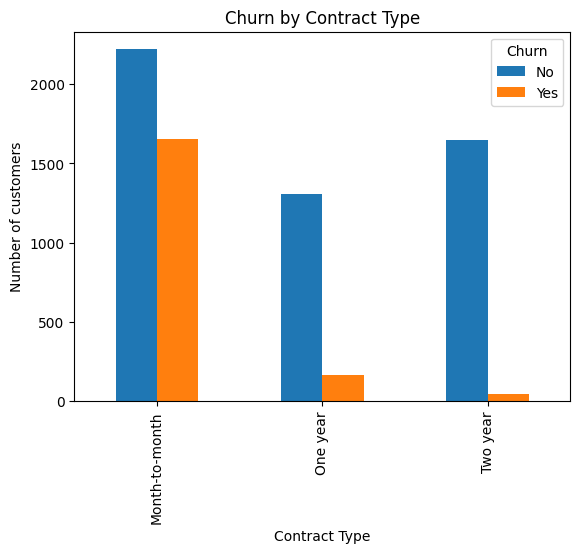

In [ ]:
pd.crosstab(df["Contract"],df["Churn"]).plot(kind="bar")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of customers")
plt.show()

In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


###Monthly charges vs Customer Churn
Customers who churn pay higher average monthly charges compared to customers who stays.
This suggests that high monthly charges may contribute to increased churn , indicating potential price sensitivity among customers,

###Recommendation
The comapny could consider offering targeted discounts or loyalty programs to customer with higher monthly charges to reduce churn risk



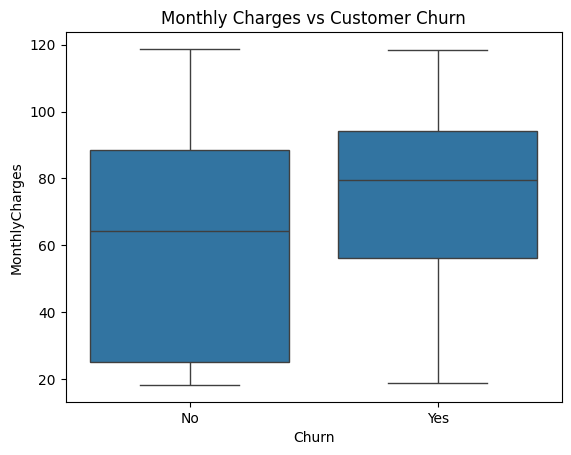

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Customer Churn")
plt.show()

In [ ]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


### Tenure vs Churn
Customers who churn have an average tenure of approximately 18 months, while customers who have an average tenure of around 37 months.
This indicates that newer customers are significantly more likely to churn, while long-term customers tend to remain loyal to the service.

### Recommendation
The comapny should focus on improving the early customer experience and engagement stratergies during the first few months of service to reduce churn among new customers.

In [ ]:
pd.crosstab(df["PaymentMethod"],df["Churn"], normalize="index")*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


### Payment Method vs Customer Churn
Customers using electronic check as their payment method have the highest churn rate(45.3%), significantly higher than other payment methods.
In contrast , customers using automatic payment methods such as bank transfer and credit card show much lower churn rates.
This suggest that automatic payment methods may improve customer retention

### Recommendation
The company should encourage customersto switch from electronic check payment methods such as credit card or bank transfer to reduce churn risk

In [ ]:
pd.crosstab(df["InternetService"],df["Churn"], normalize="index")*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### Internet Service vs Customer Churn

Customers using fiber optic internet service show the highest churn rate (41.9%), which is significantly higher than DSL customers (19%).

Customers without internet service have the lowest churn rate (7.4%).

This suggests that fiber optic service may require improvements in pricing, service quality, or customer support.

### Recommendation
The company should investigate customer satisfaction issues related to fiber optic services and consider improving service quality or pricing strategies.

In [ ]:
pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


### Tech Support vs Customer Churn

Customers without technical support show a significantly higher churn rate (41.6%) compared to customers who receive technical support (15.1%).

This indicates that providing reliable technical support plays an important role in customer retention.

### Recommendation
The company should encourage customers to subscribe to technical support services and improve support quality to reduce churn risk.

Key Findings

• Month-to-month contracts have the highest churn rate.
• Customers with higher monthly charges are more likely to churn.
• New customers churn more frequently than long-term customers.
• Electronic check users show the highest churn among payment methods.
• Fiber optic users show higher churn compared to DSL users.
• Customers without technical support are more likely to churn.

Recommendations

• Encourage customers to switch to long-term contracts.

• Offer loyalty incentives for high monthly charge customers.

• Improve early customer experience to retain new users.

• Promote automatic payment methods to reduce churn risk.

• Improve fiber optic service quality.

• Strengthen technical support services.

Conclusion

This analysis identified several key factors influencing customer churn, including contract type, pricing, tenure, and service quality.

Understanding these patterns can help the company develop targeted strategies to improve customer retention and reduce churn.